In [1]:
%load_ext autoreload

%autoreload 2
import numpy as np
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
from cosmosis.postprocessing.inputs import read_input as _cosmosis_read

In [2]:
names_both = ['7', '8', '1', '2', '3', '4', '5', '6']
labels_both = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$', r'$\Omega_8$', r'$\sigma_8$']

names_mor = ['1', '2', '3', '4', '5', '6']
labels_mor = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$']


settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

In [3]:
from cosmosis.postprocessing.inputs import read_input
def load_cosmosis_chain(
    path: str,
    param_names: list[str],
    burn_fraction: float,
    skip_cosmo = False,
    only_cosmo = False,
    label= None
) -> MCSamples:

    raw   = read_input(path)
    rows  = raw[1]["data"][1][0]
    n_par = len(param_names)
    if skip_cosmo: 
        array = np.array([[row[i] for i in range(2, n_par)] for row in rows])
        param_names = param_names[2:]
    elif only_cosmo:
        array = np.array([[row[i] for i in range(0, 2)] for row in rows])
        param_names = param_names[:2]
    else:
        array = np.array([[row[i] for i in range(n_par)] for row in rows])        
    samples = MCSamples(
        samples  = array,
        names    = param_names,
        labels   = param_names,
        settings = settings,
        label=label
    )
    samples.removeBurn(burn_fraction)
    return samples

## Baseline

In [4]:
path_baseline_mor = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
path_baseline_both = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

baseline_mor = load_cosmosis_chain(path_baseline_mor, names_mor, 0.3, label = "Baseline Counts+Lensing")
baseline_both = load_cosmosis_chain(path_baseline_both, names_both, 0.3, True, label = "Baseline Counts+Lensing")

baseline_cosmo = load_cosmosis_chain(path_baseline_both, names_both, 0.3, only_cosmo=True, label = "Baseline Counts+Lensing")


LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## HMF

In [5]:
tinker08_mor_path = "./hmf_analysis/tinker08/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
tinker10_mor_path = "./hmf_analysis/tinker10/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
watson13_mor_path = "./hmf_analysis/watson13/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
bocquet16_mor_path = "./hmf_analysis/bocquet16/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"

tinker08_mor = load_cosmosis_chain(tinker08_mor_path, names_mor, 0.3, label = "Tinker08")
tinker10_mor = load_cosmosis_chain(tinker10_mor_path, names_mor, 0.3, label = "Tinker10")
watson13_mor = load_cosmosis_chain(watson13_mor_path, names_mor, 0.3, label = "Watson13")
bocquet16_mor = load_cosmosis_chain(bocquet16_mor_path, names_mor, 0.3, label = "Bocquet16")


tinker08_both_path = "./hmf_analysis/tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
tinker10_both_path = "./hmf_analysis/tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
watson13_both_path = "./hmf_analysis/watson13/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
bocquet16_both_path = "./hmf_analysis/bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

tinker08_both = load_cosmosis_chain(tinker08_both_path, names_both, 0.3,True, label = "Tinker08")
tinker10_both = load_cosmosis_chain(tinker10_both_path, names_both, 0.3,True, label = "Tinker10")
watson13_both = load_cosmosis_chain(watson13_both_path, names_both, 0.3,True, label = "Watson13")
bocquet16_both = load_cosmosis_chain(bocquet16_both_path, names_both, 0.3,True, label = "Bocquet16")


tinker08_cosmo = load_cosmosis_chain(tinker08_both_path, names_both, 0.3,only_cosmo=True, label = "Tinker08")
tinker10_cosmo = load_cosmosis_chain(tinker10_both_path, names_both, 0.3,only_cosmo=True, label = "Tinker10")
watson13_cosmo = load_cosmosis_chain(watson13_both_path, names_both, 0.3,only_cosmo=True, label = "Watson13")
bocquet16_cosmo = load_cosmosis_chain(bocquet16_both_path, names_both, 0.3,only_cosmo=True, label = "Bocquet16")


LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker08/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker10/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/watson13/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/bocquet16/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/watson13/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/bocquet16/run_in2p3_both/outputs_bo

In [6]:
print(tinker08_cosmo)

## Delta SIgma

In [7]:
cosmo03_both_path = "./deltasigma_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
cosmo04_both_path = "./deltasigma_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

cosmo03_both = load_cosmosis_chain(cosmo03_both_path, names_both, 0.3,True, label = f"Lensing Data Cosmo $\Omega_c 0.3$")
cosmo04_both = load_cosmosis_chain(cosmo04_both_path, names_both, 0.3,True, label = f"Lensing Data Cosmo $\Omega_c 0.4$")

cosmo03_cosmo = load_cosmosis_chain(cosmo03_both_path, names_both, 0.3,only_cosmo=True, label = f"Lensing Data Cosmo $\Omega_c 0.3$")
cosmo04_cosmo = load_cosmosis_chain(cosmo04_both_path, names_both, 0.3,only_cosmo=True, label = f"Lensing Data Cosmo $\Omega_c 0.4$")



LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Selection

In [8]:
nosel_mor_path = "./selection_analysis/no_selection_full_sample/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
nofirstbin_mor_path = "./selection_analysis/exclude_first_rich_bin/run_in2p3_mor/outputs_both/output_rp/number_counts_samples.txt"

nosel_mor = load_cosmosis_chain(nosel_mor_path, names_mor, 0.3, label = "No selection, all bins")
nofirstbin_mor = load_cosmosis_chain(nofirstbin_mor_path, names_mor, 0.3, label = "No selection, No First Rich Bin")


nosel_both_path = "./selection_analysis/no_selection_full_sample/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
nofirstbin_both_path = "./selection_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

nosel_both = load_cosmosis_chain(nosel_both_path, names_both, 0.3,True, label = "No selection, all bins")
nofirstbin_both = load_cosmosis_chain(nofirstbin_both_path, names_both, 0.3,True, label = "No selection, No First Rich Bin")


nosel_cosmo = load_cosmosis_chain(nosel_both_path, names_both, 0.3,only_cosmo = True, label = "No selection, all binst")
nofirstbin_cosmo = load_cosmosis_chain(nofirstbin_both_path, names_both, 0.3,only_cosmo = True, label = "No selection, No First Rich Bin")


LOADING CHAIN FROM FILE:  ./selection_analysis/no_selection_full_sample/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./selection_analysis/exclude_first_rich_bin/run_in2p3_mor/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./selection_analysis/no_selection_full_sample/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./selection_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./selection_analysis/no_selection_full_sample/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./selection_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Payerne25 baseline

In [9]:
n_cut=19000
t = np.load(f'./payerne25chains/WLxN/MCMC_fit_m-r_WLxN_1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_low_z_sample_hmf=Despali16.pkl', allow_pickle = True)


chains = t['flat_chains'].copy()

chains[:, [1, 2]] = chains[:, [2, 1]]

chains[:, [4, 5]] = chains[:, [5, 4]]

# Scale columns 2 and 4 by 1/ln(10)
factor = 1 / np.log(10)
chains[:, [1, 4]] *= factor

WLxNbaselinelowz = MCSamples(samples=chains[n_cut:],names = names_mor, 
                    labels = labels_mor, 
                     settings=settings, 
                     label='Payerne25 Counts+Lensing')

Removed no burn in


## Counts Baseline

In [10]:
path_counts_baseline_mor = "./baseline/cosmodc2_redmapper_counts/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
path_counts_baseline_both = "./baseline/cosmodc2_redmapper_counts//run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

baseline_counts_mor = load_cosmosis_chain(path_counts_baseline_mor, names_mor, 0.3, label = "Baseline Counts")
baseline_counts_both = load_cosmosis_chain(path_counts_baseline_both, names_both, 0.3, True, label = "Baseline Counts")

baseline_counts_cosmo = load_cosmosis_chain(path_counts_baseline_both, names_both, 0.3, only_cosmo=True, label = "Counts")


LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_counts/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_counts//run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_counts//run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Lensing Baseline

In [11]:
path_lensing_baseline_mor = "./baseline/cosmodc2_redmapper_lensing/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"
path_lensing_baseline_both = "./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

baseline_lensing_mor = load_cosmosis_chain(path_lensing_baseline_mor, names_mor, 0.3, label = "Baseline Lensing")
baseline_lensing_both = load_cosmosis_chain(path_lensing_baseline_both, names_both, 0.3, True, label = "Baseline Lensing")

baseline_lensing_cosmo = load_cosmosis_chain(path_lensing_baseline_both, names_both, 0.3, only_cosmo=True, label = "Lensing")


LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_lensing/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


In [12]:
list_chain_baseline = [baseline_mor, WLxNbaselinelowz]
likelihood_baseline = ["Counts+Lensing", "Payerne25 Counts+Lensing"]
list_chains_hmf = [tinker08_mor, tinker10_mor, bocquet16_mor, watson13_mor]
likelihood_hmf = ['tinker08_mor', 'tinker10_mor', 'bocquet16_mor', 'watson13_mor']
list_chains_sel = [nosel_mor, nofirstbin_mor]
likelihood_sel = ['nosel_mor', 'nofirstbin_mor']

sections = [list_chain_baseline, list_chains_hmf, list_chains_sel]
color_section = ['C0', 'C1', 'C2', 'C3']
baseline_per_section = [baseline_mor, baseline_mor, baseline_mor]

In [13]:
sections_name = ['Baseline', 'HMF', 'No Selection']

In [14]:

truth = {'1': 3.345953364933381,
 '2': 0.958236982,
 '3': -0.0192802,
 '4': 0.562317194,
 '5': 0.04552506,
 '6': -0.0445}




mcmc_baseline_mean = baseline_mor.mean(['1', '2', '3', '4', '5', '6'])
mcmc_baseline_error = np.diagonal(baseline_mor.cov(['1', '2', '3', '4', '5', '6']))**.5

Baseline Counts+Lensing [ 3.33613731  0.93943512 -0.28582391  0.53554995  0.02460234  0.46636732]
Payerne25 Counts+Lensing [ 3.32375656  0.94550889 -0.08083958  0.54753366  0.03843996  0.25001235]
Tinker08 [ 3.3628431   0.95103665 -0.26694744  0.51086982  0.02754692  0.50016873]
Tinker10 [ 3.2226569   1.00356739 -0.65549415  0.5718441  -0.02839258  0.59691172]
Bocquet16 [ 3.22572453  0.97359945 -0.60970272  0.57232783 -0.01967784  0.55360597]
Watson13 [ 3.02545188  0.96203083  0.01735518  0.65162233 -0.07129053  0.10976261]
No selection, all bins [ 3.33692234  0.99660886 -0.43450196  0.5318742   0.02890182  0.48444184]
No selection, No First Rich Bin [ 3.35864011  0.988971   -0.12580095  0.51741726  0.04298736  0.38962414]


Text(0.5, 0, '$\\sigma_0$')

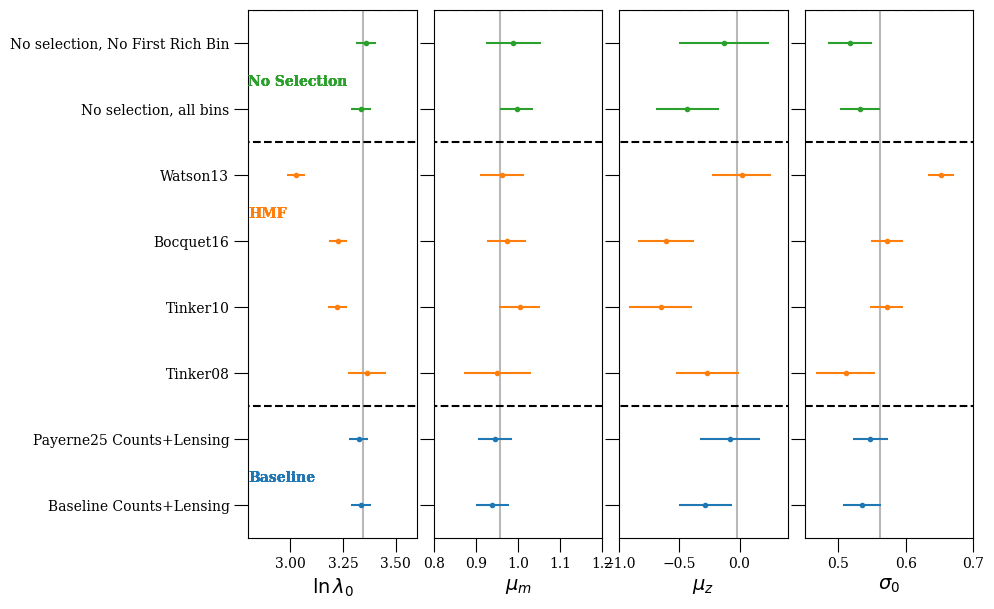

In [15]:
%matplotlib inline
number_of_params = 4
fig, ax = plt.subplots(1,number_of_params,figsize=(10,7), sharey = True)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=.1, hspace=0)
s = 0

for l, section in enumerate(sections):
    color = color_section[l]
    mcmc_baseline_mean = baseline_per_section[l].mean(['1', '2', '3', '4', '5', '6'])
    mcmc_baseline_error = np.diagonal(baseline_per_section[l].cov(['1', '2', '3', '4', '5', '6']))**.5
    for k in range(len(section)):
        mcmc = section[k]
        means = mcmc.mean(['1', '2', '3', '4', '5', '6'])
        print(mcmc.label, means)
        errors = np.diagonal(mcmc.cov(['1', '2', '3', '4', '5', '6']))**.5
        for j in range(number_of_params):
            ax[j].errorbar(means[j], mcmc.label, xerr=errors[j], marker='.', color=color)
            #ax[j].errorbar(nsigma_truth[j], mcmc.label, marker = 'o', color = color, alpha=.8)
        s_start = s
        s = s +1
    for j in range(number_of_params):
        t = [truth[str(k+1)] for k in range(len(truth))]
        ax[j].hlines(s-.5, -2, 10,ls='--', color = 'k')
        ax[j].vlines(t[j], -10, 100,ls='-', color = 'k', alpha=.1, zorder=0)
        #ax[j].set_xlim(-2, 2)
        ax[j].set_ylim(-.5, 7.5)
        ax[j].tick_params(axis='both', which="both", labelsize= 10)
        ax[0].text(2.8, (s_start + s - 2.3) / 2, sections_name[l],
                   ha='left', color=color_section[l], fontweight='bold', fontsize=10)
ax[0].set_xlim(2.8, 3.6)
ax[1].set_xlim(0.8, 1.2)
ax[2].set_xlim(-1, 0.4)
ax[3].set_xlim(0.45, 0.7)
# ax[4].set_xlim(-0.5, 0.5)
# ax[5].set_xlim(-0.5, 0.5)


ax[0].set_xlabel(r'$\ln \lambda_0$', fontsize=14)
ax[1].set_xlabel(r'$\mu_m$', fontsize=14)
ax[2].set_xlabel(r'$\mu_z$', fontsize=14)
ax[3].set_xlabel(r'$\sigma_0$', fontsize=14)
# ax[4].set_xlabel(r'$\sigma_m$', fontsize=14)
# ax[5].set_xlabel(r'$\sigma_z$', fontsize=14)
#plt.savefig(f'../fig_erratum/summary_fits.png', dpi = 300, bbox_inches='tight',)

In [16]:
list_chain_baseline = [baseline_both]
likelihood_baseline = ["Counts+Lensing"]
list_chains_hmf = [tinker08_both, tinker10_both, bocquet16_both, watson13_both]
likelihood_hmf = ['tinker08_both', 'tinker10_both', 'bocquet16_both', 'watson13_both']
list_chains_sel = [nosel_both, nofirstbin_both]
likelihood_sel = ['nosel_both', 'nofirstbin_both']
list_chains_ds = [cosmo03_both, cosmo04_both]
likelihood_ds = ['cosmo03_both', 'cosmo04_both']
sections = [list_chain_baseline, list_chains_hmf, list_chains_sel, list_chains_ds]
color_section = ['C0', 'C1', 'C2', 'C3']
baseline_per_section = [baseline_mor, baseline_mor, baseline_mor, baseline_mor]
sections_name = ['Baseline', 'HMF', 'No Selection', f'Lensing $\Omega_c$']

Baseline Counts+Lensing [ 3.39827233  0.98972015 -0.06795521  0.4875842   0.01297425  0.40446632]
Tinker08 [ 3.38353599e+00  1.00956065e+00 -2.21537865e-01  4.87697866e-01
 -1.76228224e-03  4.97476962e-01]
Tinker10 [ 3.44457358  1.07016017 -0.19052096  0.44563221 -0.00736981  0.53032261]
Bocquet16 [ 3.44423547  1.02946988 -0.2867276   0.45103306  0.00718435  0.5910868 ]
Watson13 [ 3.40530241  0.94508995 -0.05138015  0.49239382  0.02776096  0.36447698]
No selection, all bins [ 3.31152542  1.04550783 -0.00718357  0.52427876 -0.0036273   0.25939615]
No selection, No First Rich Bin [2.93649554 0.94587377 0.07541973 0.68030537 0.02443668 0.13066189]
Lensing Data Cosmo $\Omega_c 0.3$ [ 3.36317335e+00  9.89639249e-01 -1.20192807e-01  4.91648567e-01
 -2.78871349e-04  4.23326572e-01]
Lensing Data Cosmo $\Omega_c 0.4$ [ 3.32589853  0.96896111 -0.14471818  0.50575965  0.00919533  0.39499939]


Text(0.5, 0, '$\\sigma_0$')

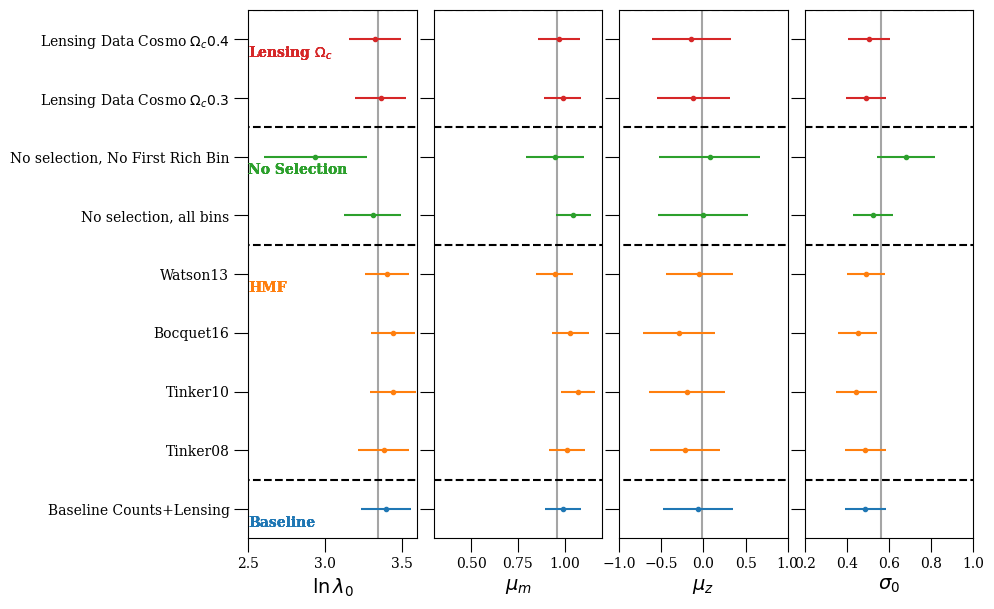

In [17]:
%matplotlib inline
number_of_params = 4
fig, ax = plt.subplots(1,number_of_params,figsize=(10,7), sharey = True)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=.1, hspace=0)
s = 0

for l, section in enumerate(sections):
    color = color_section[l]
    mcmc_baseline_mean = baseline_per_section[l].mean(['1', '2', '3', '4', '5', '6'])
    mcmc_baseline_error = np.diagonal(baseline_per_section[l].cov(['1', '2', '3', '4', '5', '6']))**.5
    for k in range(len(section)):
        mcmc = section[k]
        means = mcmc.mean(['1', '2', '3', '4', '5', '6'])
        print(mcmc.label, means)
        errors = np.diagonal(mcmc.cov(['1', '2', '3', '4', '5', '6']))**.5
        for j in range(number_of_params):
            ax[j].errorbar(means[j], mcmc.label, xerr=errors[j], marker='.', color=color)
            #ax[j].errorbar(nsigma_truth[j], mcmc.label, marker = 'o', color = color, alpha=.8)
        s_start = s
        s = s +1
    for j in range(number_of_params):
        t = [truth[str(k+1)] for k in range(len(truth))]
        ax[j].hlines(s-.5, -2, 10,ls='--', color = 'k')
        ax[j].vlines(t[j], -10, 100,ls='-', color = 'k', alpha=.1, zorder=0)
        #ax[j].set_xlim(-2, 2)
        ax[j].set_ylim(-.5, 8.5)
        ax[j].tick_params(axis='both', which="both", labelsize= 10)
        ax[0].text(2.5, (s_start + s - 1.6) / 2, sections_name[l],
                   ha='left', color=color_section[l], fontweight='bold', fontsize=10)
ax[0].set_xlim(2.5, 3.6)
ax[1].set_xlim(0.3, 1.2)
ax[2].set_xlim(-1, 1)
ax[3].set_xlim(0.2, 1.0)
# ax[4].set_xlim(-0.5, 0.5)
# ax[5].set_xlim(-0.5, 0.5)


ax[0].set_xlabel(r'$\ln \lambda_0$', fontsize=14)
ax[1].set_xlabel(r'$\mu_m$', fontsize=14)
ax[2].set_xlabel(r'$\mu_z$', fontsize=14)
ax[3].set_xlabel(r'$\sigma_0$', fontsize=14)
# ax[4].set_xlabel(r'$\sigma_m$', fontsize=14)
# ax[5].set_xlabel(r'$\sigma_z$', fontsize=14)
#plt.savefig(f'../fig_erratum/summary_fits.png', dpi = 300, bbox_inches='tight',)

In [18]:
list_chain_baseline = [baseline_cosmo, baseline_counts_cosmo, baseline_lensing_cosmo]
likelihood_baseline = ["Counts+Lensing", "Counts", "Lensing"]
list_chains_hmf = [tinker08_cosmo, tinker10_cosmo, bocquet16_cosmo, watson13_cosmo]
likelihood_hmf = ['tinker08_cosmo', 'tinker10_cosmo','bocquet16_cosmo', 'watson13_cosmo']
list_chains_sel = [nosel_cosmo, nofirstbin_cosmo]
likelihood_sel = ['nosel_cosmo', 'nofirstbin_cosmo']
list_chains_ds = [cosmo03_cosmo, cosmo04_cosmo]
likelihood_ds = [f'$\Omega_c 03$', f'$\Omega_c 04$']


sections = [list_chain_baseline, list_chains_hmf, list_chains_sel, list_chains_ds]
color_section = ['C0', 'C1', 'C2', 'C3']
baseline_per_section = [baseline_cosmo, baseline_cosmo, baseline_cosmo,baseline_cosmo]

sections_name = ['Baseline', 'HMF', 'No Selection', f'Lensing $\Omega_c$']


truth = {'7': 0.22,
 '8': 0.8}




Baseline Counts+Lensing [0.24093295 0.77878268]
Counts [0.26984049 0.79052384]
Lensing [0.26128299 0.79215793]
Tinker08 [0.23479193 0.78971306]
Tinker10 [0.23382378 0.76473704]
Bocquet16 [0.22805707 0.76859914]
Watson13 [0.20440937 0.78806344]
No selection, all binst [0.25437058 0.77760858]
No selection, No First Rich Bin [0.28727972 0.81952495]
Lensing Data Cosmo $\Omega_c 0.3$ [0.23743224 0.78843451]
Lensing Data Cosmo $\Omega_c 0.4$ [0.23331383 0.80007001]


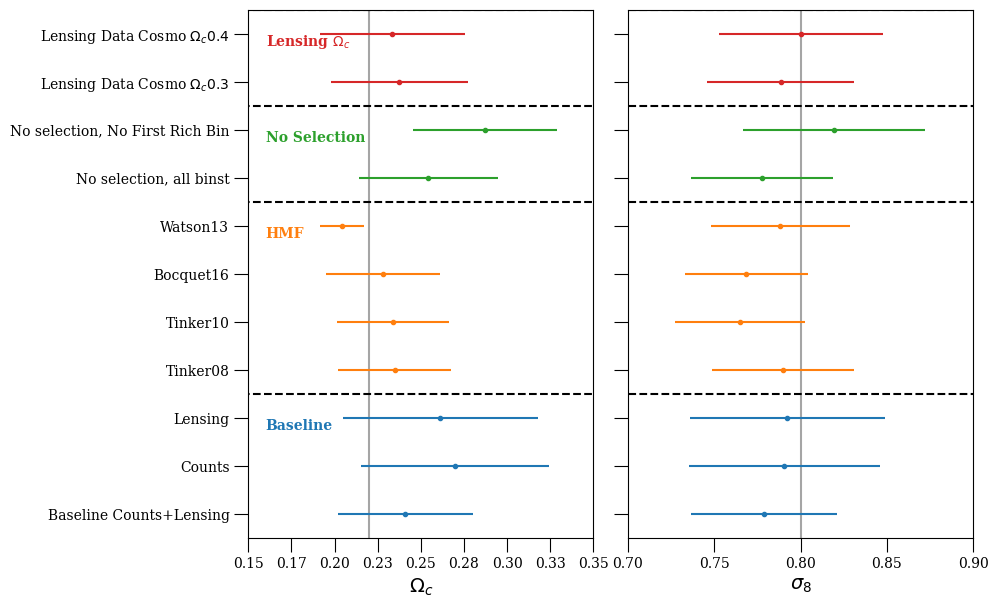

In [19]:
from matplotlib.ticker import FormatStrFormatter
number_of_params = 2
fig, ax = plt.subplots(1, number_of_params, figsize=(10, 7), sharey=True)
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=.1, hspace=0)
s = 0

for l, section in enumerate(sections):
    color = color_section[l]
    mcmc_baseline_mean = baseline_per_section[l].mean(['7', '8'])
    mcmc_baseline_error = np.diagonal(baseline_per_section[l].cov(['7', '8']))**.5
    for k in range(len(section)):
        mcmc = section[k]
        means = mcmc.mean(['7', '8'])
        print(mcmc.label, means)
        errors = np.diagonal(mcmc.cov(['7', '8']))**.5
        for j in range(number_of_params):
            ax[j].errorbar(means[j], mcmc.label, xerr=errors[j], marker='.', color=color)
        s_start = s
        s = s + 1
    for j in range(number_of_params):
        t = [0.22, 0.8]
        ax[j].hlines(s - .5, -2, 10, ls='--', color='k')
        ax[j].vlines(t[j], -10, 100, ls='-', color='k', alpha=.1, zorder=0)
        ax[j].set_ylim(-0.5, s - 0.5)
        ax[j].tick_params(axis='both', which="both", labelsize=10)
    # FIX: place text at x=0.16 (inside xlim) instead of x=2.5
    ax[0].text(0.16, (s_start + s - 1.5) / 2, sections_name[l],
               ha='left', color=color_section[l], fontweight='bold', fontsize=10)
ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[0].set_xlim(0.15, 0.35)
ax[1].set_xlim(0.7, 0.9)

ax[0].set_xlabel(r'$\Omega_c$', fontsize=14)
ax[1].set_xlabel(r'$\sigma_8$', fontsize=14)
plt.show()